In [3]:
"""
This script loads in responses from classification csv file output by Zooniverse,
and normalizes them into a table with one row per task answered
"""
import json
import logging
import sqlite3
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

# PARAMETERS
classifications_csv_path = 'survey_responses/may-survey-classifications_2025-06-17.csv'
output_dir = 'survey_responses/analysis/may'
ml_responses_database_path = 'records_bedrock.db'
subjects_path = 'survey_responses/review-llm-responses-on-lca-tasks-subjects.csv'
workflow_id = 28845

In [32]:
import seaborn as sns
sns.set_theme(style="darkgrid")
# Wrap x-tick labels and rotate
def wrap_labels(ax, width, break_long_words=True):
    xlabels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        parts = text.split('-')
        wrapped_parts = [textwrap.fill(part, width=width, break_long_words=break_long_words) for part in parts]
        wrapped_text = ' '.join(wrapped_parts)
        xlabels.append(wrapped_text)
    ax.set_xticks(ax.get_xticks())  # Set ticks explicitly
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    ylabels=[]
    for label in ax.get_yticklabels():
        text = label.get_text()
        ylabels.append(textwrap.fill(text, width=width, break_long_words=break_long_words))
    ax.set_yticks(ax.get_yticks())  # Set ticks explicitly
    ax.set_yticklabels(ylabels, rotation=45, ha='right')

# Load data

In [4]:
current_date = datetime.now().strftime('%Y%m%d')

logging.basicConfig(level=logging.INFO)

# Read classifications
classifications_df = pd.read_csv(classifications_csv_path)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

subjects_df = pd.read_csv(subjects_path)
# Extract the prompt_id, llm model and other data from the metadata column
subjects_df = subjects_df.loc[subjects_df.workflow_id==workflow_id]
metadata_df = subjects_df['metadata'].apply(json.loads).apply(pd.Series)
subjects_df = pd.concat([subjects_df, metadata_df], axis=1)

# TODO: Prompts and responses in one database
# TODO: filter out questions that were withdrawn
prompts_database_path = 'records_cajetan.db'
conn = sqlite3.connect(prompts_database_path)
prompts_df = pd.read_sql('''select * from prompts''', conn)
ml_responses_database_path = 'records_may_all.db'
conn = sqlite3.connect(ml_responses_database_path)
ml_responses_df = pd.read_sql('select * from responses', conn)


# Plot responses over time

In [5]:
import textwrap
import seaborn as sns
sns.set_theme(style="darkgrid")
# Wrap x-tick labels and rotate
def wrap_labels(ax, width, break_long_words=True):
    xlabels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        parts = text.split('-')
        wrapped_parts = [textwrap.fill(part, width=width, break_long_words=break_long_words) for part in parts]
        wrapped_text = ' '.join(wrapped_parts)
        xlabels.append(wrapped_text)
    ax.set_xticks(ax.get_xticks())  # Set ticks explicitly
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    ylabels=[]
    for label in ax.get_yticklabels():
        text = label.get_text()
        ylabels.append(textwrap.fill(text, width=width, break_long_words=break_long_words))
    ax.set_yticks(ax.get_yticks())  # Set ticks explicitly
    ax.set_yticklabels(ylabels, rotation=45, ha='right')

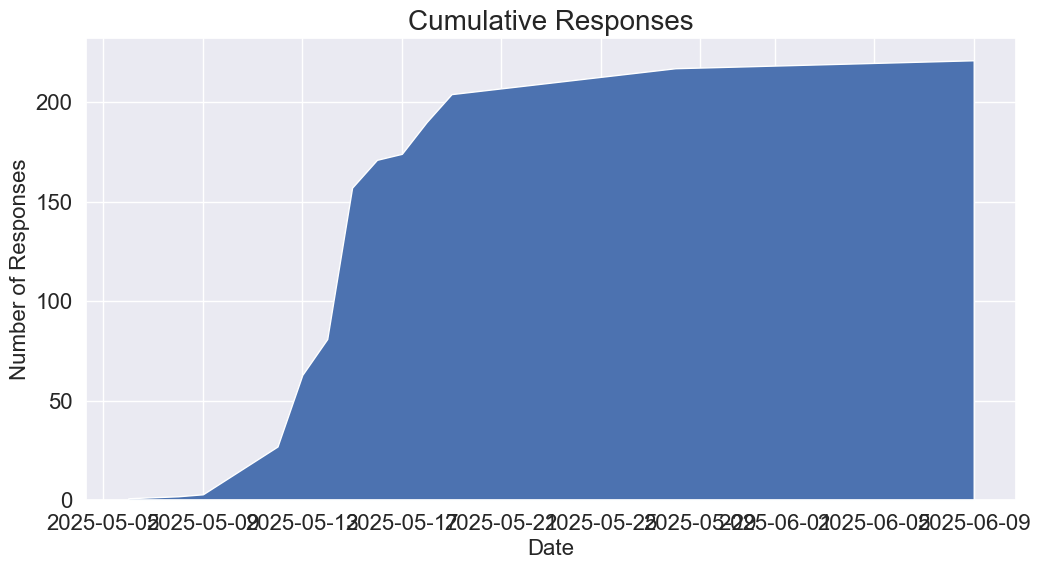

In [7]:
# Plot the cumulative time series
classification_id = classifications_df.classification_id

# Group the data by date and count the number of responses
classifications_df['created_at'] = pd.to_datetime(classifications_df['created_at'])
classifications_df['date'] = classifications_df['created_at'].dt.date
responses_per_day = classifications_df.groupby('date').size()

# Calculate the cumulative sum of responses
cumulative_responses = responses_per_day.cumsum()
plt.figure(figsize=(12, 6))
plt.stackplot(cumulative_responses.index,cumulative_responses.values)
plt.title('Cumulative Responses',fontsize=20)
plt.xlabel('Date',fontsize=16)
plt.ylabel('Number of Responses',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.savefig(output_dir/'responses_timeline_cum.png')


In [8]:
from analyze_responses_q1 import get_count_completed_tasks

# Count complete answers
classifications_df[['count_completed_tasks', 'final_completed_task_no']] = classifications_df.annotations.apply(
    get_count_completed_tasks)
print('Count completed tasks (note some tasks are optional)')
print(classifications_df.count_completed_tasks.value_counts())
print('Final completed task number')
print(classifications_df.final_completed_task_no.value_counts())


Count completed tasks (note some tasks are optional)
count_completed_tasks
6     138
7      41
8      18
9      15
10      9
Name: count, dtype: int64
Final completed task number
final_completed_task_no
8     205
9      10
10      6
Name: count, dtype: int64


In [9]:
from analyze_responses_q1 import explode_tasks

# Combine with the subject data, to get the llm name, the prompt text, etc
# Explode the annotations column
exploded_dfs = classifications_df['annotations'].apply(explode_tasks)
exploded_df = pd.concat(exploded_dfs.values, keys=exploded_dfs.index,
                        names=['original_index', 'task_index']).reset_index(level='task_index', drop=True)
# Pivot the DataFrame to have one column per task
pivoted_df = exploded_df.pivot(columns='task', values='value').reset_index()
# Re-insert the classification_ids
pivoted_df['subject_id'] = classifications_df.loc[pivoted_df['original_index'], 'subject_ids'].values
# Merge and set dtype of prompt_id
combined_df = pivoted_df.merge(subjects_df,on='subject_id',how='inner')
combined_df.prompt_id = combined_df.prompt_id.astype(int)

# Merge with prompts
combined_final = combined_df.merge(prompts_df, on='prompt_id')

# Check if the number of rows in the merged dataframe differs from the number of rows in the left dataframe
if combined_final.shape[0] != combined_df.shape[0]:
    logging.error(
        f"The number of rows in the merged dataframe ({combined_final.shape[0]}) when merging combined_df on prompts_df differs from the number of rows in the left dataframe ({combined_df.shape[0]}).")
    exit()

In [10]:
combined_final.value_counts(subset=['prompt_id','prompt_text'])

prompt_id  prompt_text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


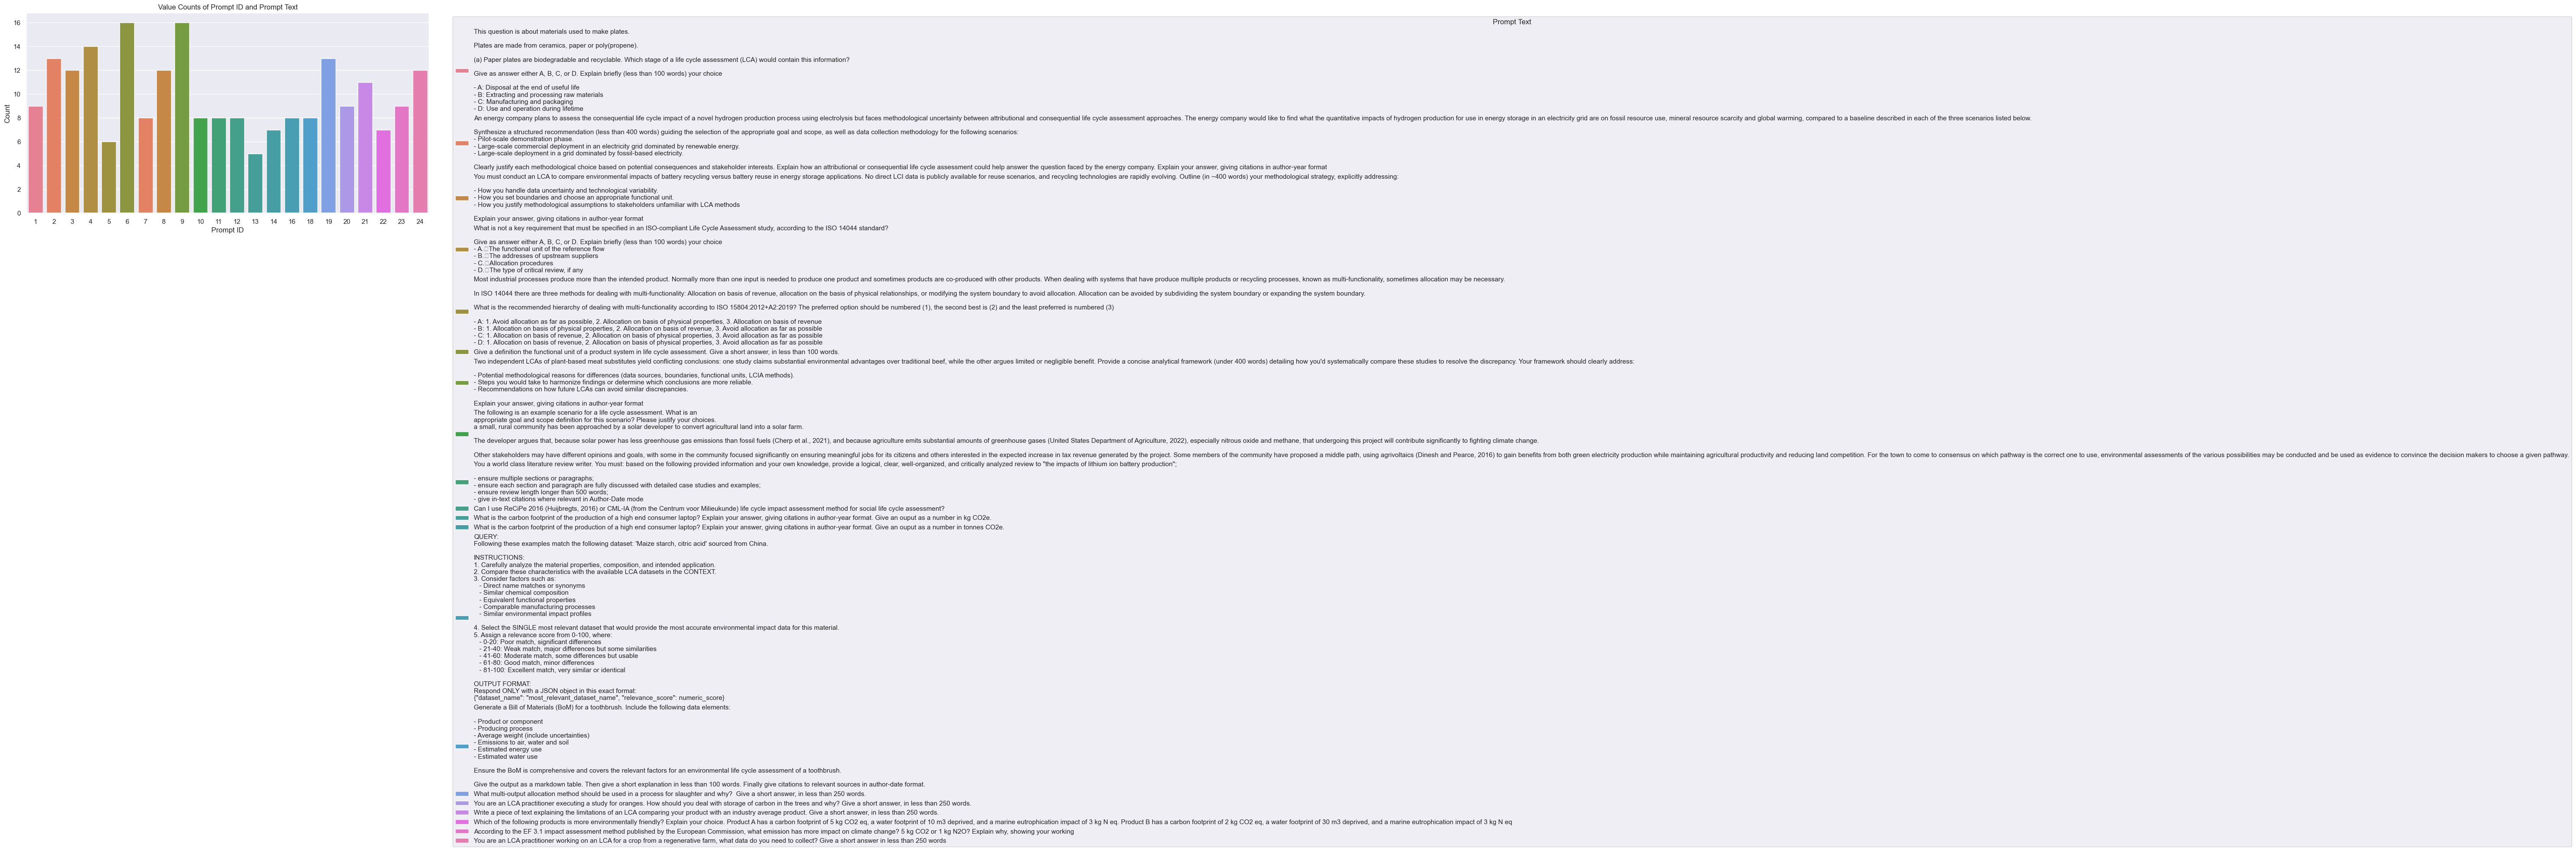

In [11]:
# Calculate value counts for the specified columns
value_counts = combined_final.value_counts(subset=['prompt_id', 'prompt_text'])

# Reset the index to turn the Series into a DataFrame
value_counts_df = value_counts.reset_index(name='count')

# Plot the bar chart using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='prompt_id', y='count', hue='prompt_text', data=value_counts_df)
plt.title('Value Counts of Prompt ID and Prompt Text')
plt.xlabel('Prompt ID')
plt.ylabel('Count')
plt.legend(title='Prompt Text', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

C:\Users\Artur\AppData\Local\Temp\ipykernel_15620\953209974.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='#llm_model', y='count', data=grouped_counts, palette='viridis')


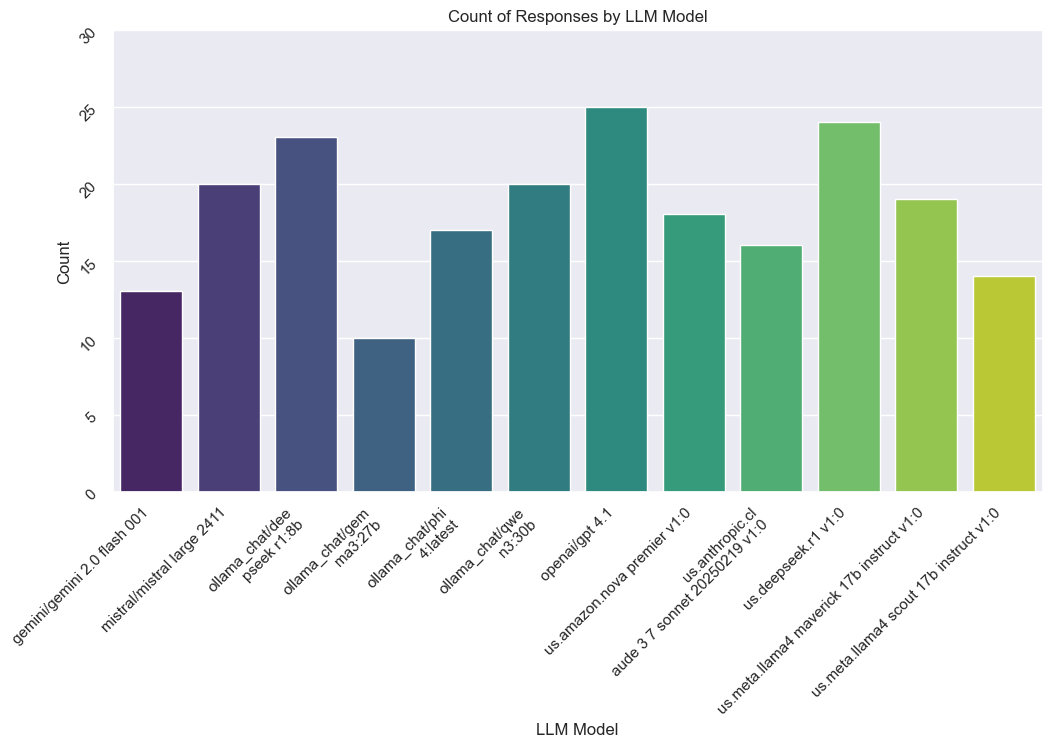

In [12]:
# Group by the 'llm_model' column and calculate the count of each group
grouped_counts = combined_final.groupby('#llm_model').size().reset_index(name='count')

# Plot the bar chart using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='#llm_model', y='count', data=grouped_counts, palette='viridis')
plt.title('Count of Responses by LLM Model')
plt.xlabel('LLM Model')
plt.ylabel('Count')
plt.xticks(rotation=45)
import textwrap

wrap_labels(plt.gca(), width=15)

plt.show()

In [13]:
grouped_counts

,#llm_model,count
0,gemini/gemini-2.0-flash-001,13
1,mistral/mistral-large-2411,20
2,ollama_chat/deepseek-r1:8b,23
3,ollama_chat/gemma3:27b,10
4,ollama_chat/phi4:latest,17
5,ollama_chat/qwen3:30b,20
6,openai/gpt-4.1,25
7,us.amazon.nova-premier-v1:0,18
8,us.anthropic.claude-3-7-sonnet-20250219-v1:0,16
9,us.deepseek.r1-v1:0,24


# Dump data

In [14]:
combined_final.to_excel(output_dir / f'{Path(classifications_csv_path).name}_analysis_{current_date}.xlsx')

# Analyse Q2

In [15]:
summary_q2 = combined_final.T2.value_counts()

In [16]:
summary_q2

T2
3 - good                          102
2 - average                        60
1 - poor                           40
4 - expert / better than human     17
Name: count, dtype: int64

In [17]:
# map t2 to numerical values
rating_description_to_number = {"3 - good": 3,
"2 - average": 2,
"1 - poor": 1,
"4 - expert / better than human": 4}

In [18]:
combined_final['T2_score']=combined_final['T2'].apply(lambda x: rating_description_to_number[x])

In [19]:
combined_final.columns

Index(['original_index', 'T1', 'T10', 'T11', 'T12', 'T2', 'T3', 'T4', 'T6',
       'T7', 'T8', 'T9', 'subject_id', 'project_id', 'workflow_id',
       'subject_set_id', 'metadata', 'locations', 'classifications_count',
       'retired_at', 'retirement_reason', 'created_at', 'updated_at',
       '#date_run', 'prompt_id', '#llm_model', 'response_id', '#temperature',
       '#llm_provider', '#prompt_run_by', 'prompt_text', 'T2_score'],
      dtype='object')

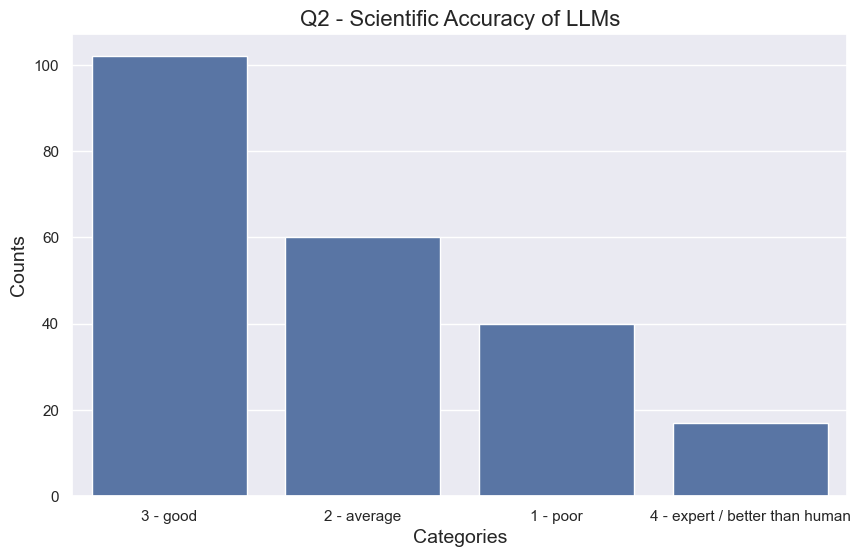

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=summary_q2.index, y=summary_q2.values)
plt.title('Q2 - Scientific Accuracy of LLMs',fontsize=16)
plt.xlabel('Categories',fontsize=14)
plt.ylabel('Counts',fontsize=14)
plt.show()

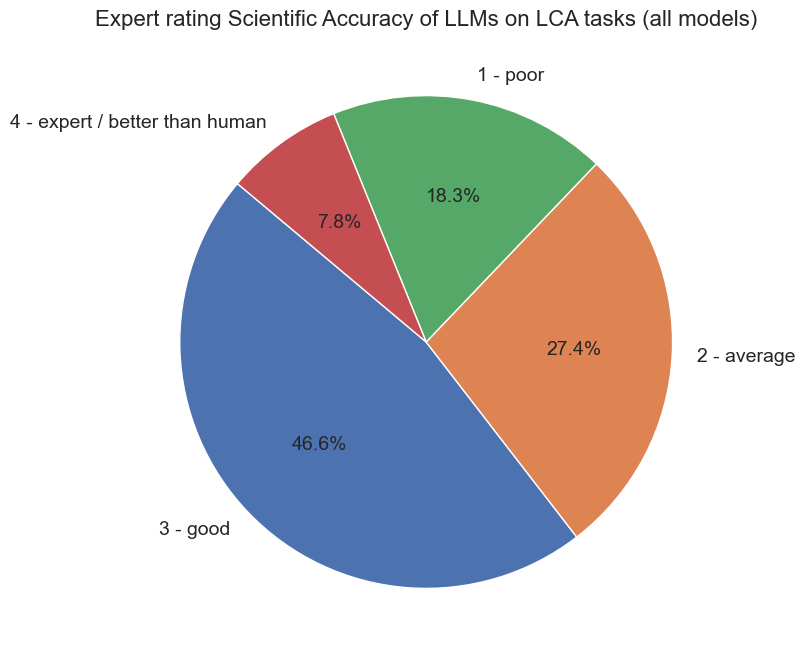

In [21]:
# Pie Chart with larger text
plt.figure(figsize=(8, 8))
plt.pie(summary_q2.values, labels=summary_q2.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title('Expert rating Scientific Accuracy of LLMs on LCA tasks (all models)', fontsize=16)
plt.show()

In [22]:
q2_by_model = combined_final.groupby(['#llm_model', 'T2_score']).size().unstack(fill_value=0)

In [23]:
q2_by_model

T2_score,1,2,3,4
#llm_model,,,,
gemini/gemini-2.0-flash-001,1,4,4,4
mistral/mistral-large-2411,4,6,10,0
ollama_chat/deepseek-r1:8b,8,8,7,0
ollama_chat/gemma3:27b,3,2,5,0
ollama_chat/phi4:latest,3,4,10,0
ollama_chat/qwen3:30b,4,6,5,5
openai/gpt-4.1,0,6,17,2
us.amazon.nova-premier-v1:0,2,5,9,2
us.anthropic.claude-3-7-sonnet-20250219-v1:0,4,4,8,0


In [24]:
model_t2_mean = combined_final.groupby('#llm_model')['T2_score'].mean().sort_values(ascending=False)
print(model_t2_mean)


#llm_model
gemini/gemini-2.0-flash-001                     2.846154
openai/gpt-4.1                                  2.840000
us.amazon.nova-premier-v1:0                     2.611111
us.meta.llama4-scout-17b-instruct-v1:0          2.571429
ollama_chat/qwen3:30b                           2.550000
us.meta.llama4-maverick-17b-instruct-v1:0       2.421053
ollama_chat/phi4:latest                         2.411765
us.deepseek.r1-v1:0                             2.333333
mistral/mistral-large-2411                      2.300000
us.anthropic.claude-3-7-sonnet-20250219-v1:0    2.250000
ollama_chat/gemma3:27b                          2.200000
ollama_chat/deepseek-r1:8b                      1.956522
Name: T2_score, dtype: float64


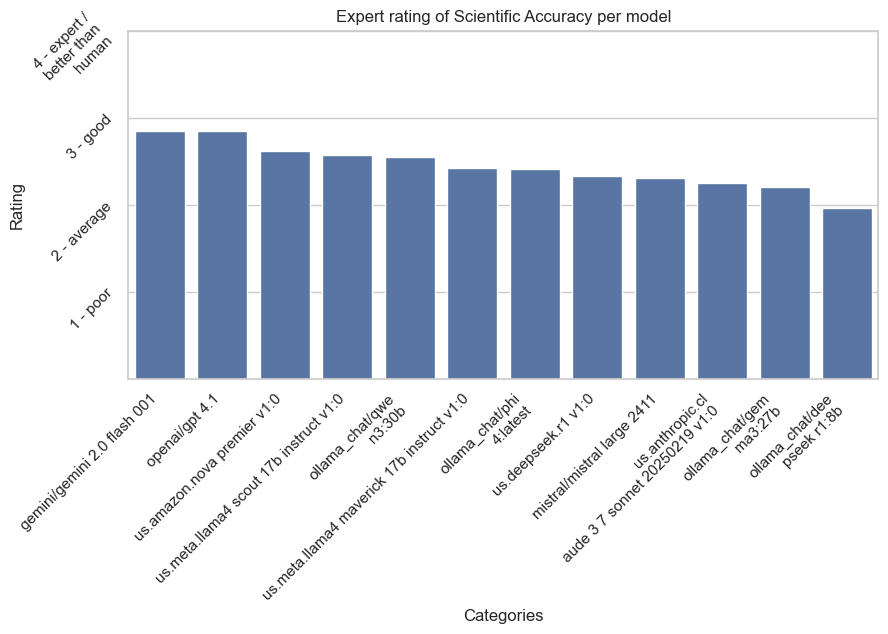

In [25]:



# Count Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_t2_mean.index,y=model_t2_mean.values)
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))


plt.subplots_adjust(left=0.15, bottom=0.3)
wrap_labels(plt.gca(), width=15)

plt.savefig(output_dir/f'{current_date}_q2_scientific_accuracy_per_model.png')
plt.show()



# The same, but take the median

In [26]:
model_t2_median = combined_final.groupby('#llm_model')['T2_score'].median().sort_values(ascending=False)
print(model_t2_mean)


#llm_model
gemini/gemini-2.0-flash-001                     2.846154
openai/gpt-4.1                                  2.840000
us.amazon.nova-premier-v1:0                     2.611111
us.meta.llama4-scout-17b-instruct-v1:0          2.571429
ollama_chat/qwen3:30b                           2.550000
us.meta.llama4-maverick-17b-instruct-v1:0       2.421053
ollama_chat/phi4:latest                         2.411765
us.deepseek.r1-v1:0                             2.333333
mistral/mistral-large-2411                      2.300000
us.anthropic.claude-3-7-sonnet-20250219-v1:0    2.250000
ollama_chat/gemma3:27b                          2.200000
ollama_chat/deepseek-r1:8b                      1.956522
Name: T2_score, dtype: float64


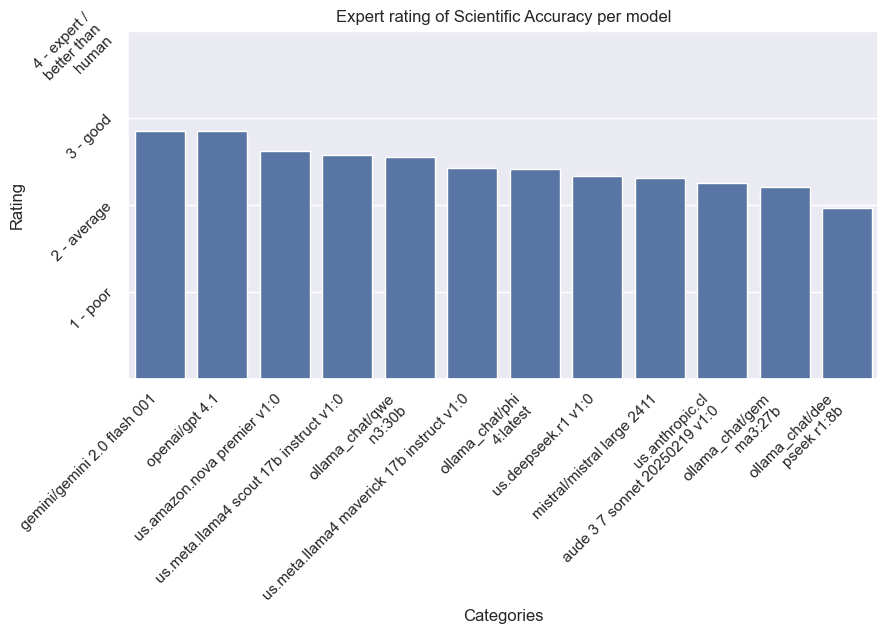

In [27]:
import textwrap
sns.set_theme(style="darkgrid")

# Count Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_t2_mean.index,y=model_t2_mean.values)
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))


plt.subplots_adjust(left=0.15, bottom=0.3)
wrap_labels(plt.gca(), width=15)

plt.savefig(output_dir/f'{current_date}_q2_scientific_accuracy_per_model_median.png')
plt.show()



# Violin plot

In [28]:
# Add count of datapoints per model to combined_df
counts_per_model = combined_final.groupby('#llm_model').T2.agg(len).to_dict()

combined_final['data_points_per_model'] = combined_final['#llm_model'].apply(lambda x: counts_per_model[x])

C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarnin

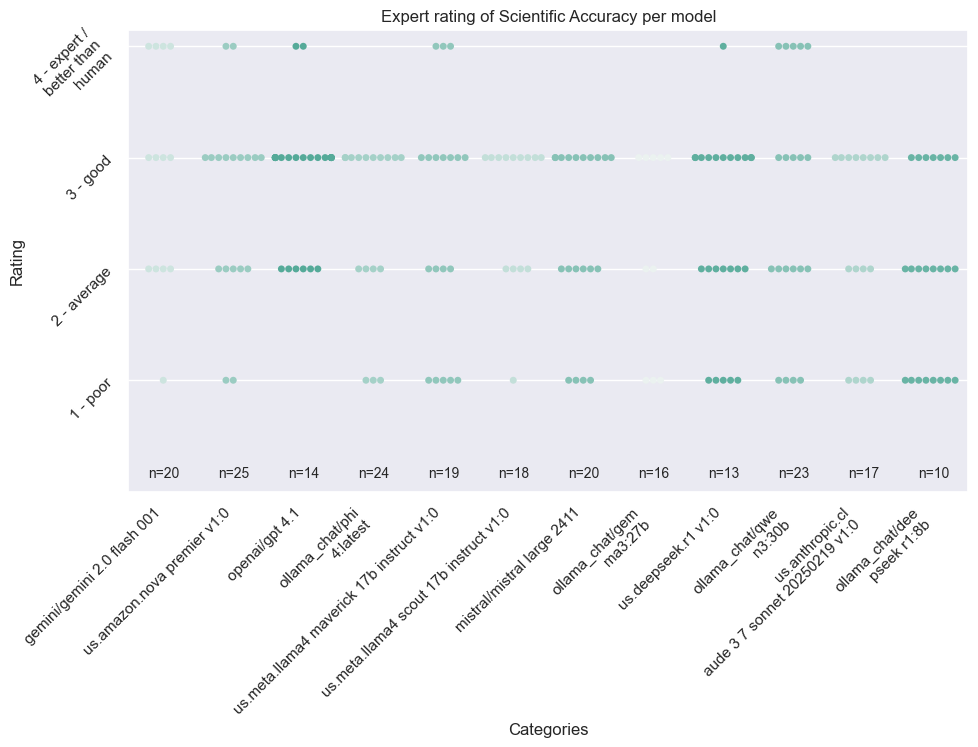

In [29]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys
ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0,'')
# Violin Plot

plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.swarmplot(x='#llm_model', y='T2_score', data=combined_final,order=list(model_t2_median.index),hue='data_points_per_model',palette=colors)
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0,5,1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)


# Add number of data points to each bar
for i, model in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == model]['T2_score'].count()
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={count}', ha='center', va='bottom', fontsize=10)

ax.get_legend().remove()
plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir/f'{current_date}_q2_scientific_accuracy_per_model_violin.png')

plt.show()

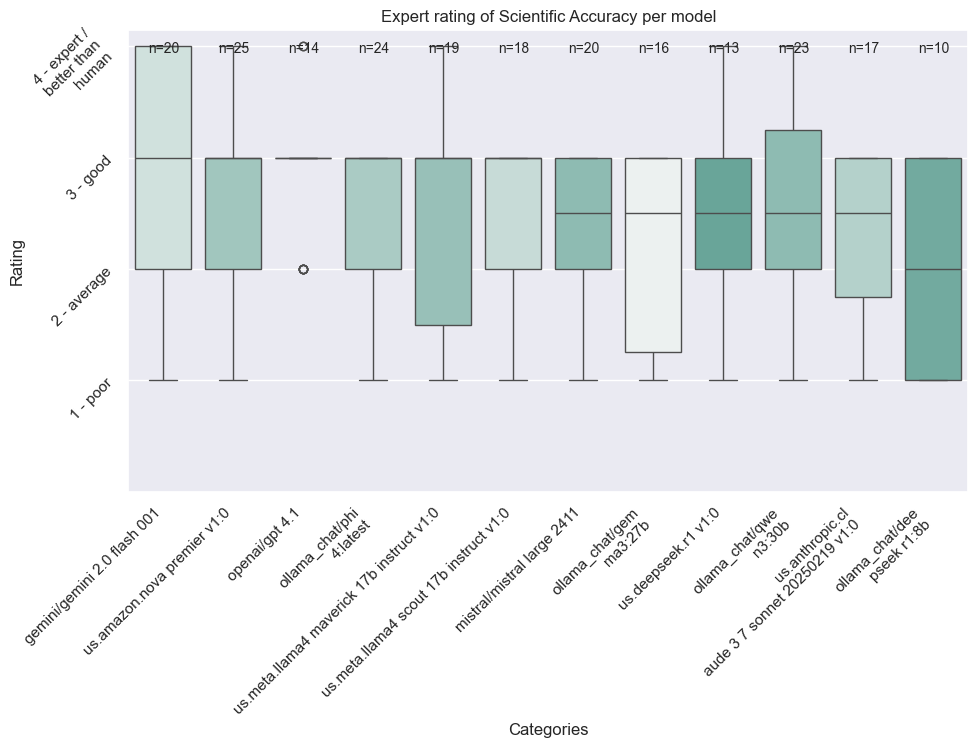

In [30]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys

ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0, '')

# Whisker Plot
plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.boxplot(x='#llm_model', y='T2_score', data=combined_final, order=list(model_t2_median.index), hue='data_points_per_model', palette=colors)
plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0, 5, 1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)

# Add number of data points to each bar
for i, model in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == model]['T2_score'].count()
    ax.text(i, ax.get_ylim()[1] - 0.1, f'n={count}', ha='center', va='top', fontsize=10)

ax.get_legend().remove()
plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir / f'{current_date}_q2_scientific_accuracy_per_model_whisker.png')

plt.show()

In [31]:
ylabels_text

['', '1 - poor', '2 - average', '3 - good', '4 - expert / better than human']

# Analyze comments on Q2

In [33]:
combined_final.T7.drop_duplicates()

0                   Correct answer, and good explanation
1                                                       
3      The reasoning make sense and the value seems a...
7      response is accurate, but a notice that the pr...
8      Some claims and numbers are wrong and not supp...
9      Generally correct, but misses information on t...
10     LCA is not designed to enylze impacts from pop...
11     Good response, but misses some detail on the +...
12     misses the allocation hierachy and reference t...
13     The answer is properly drafted. It is a pity i...
14     The answer does not refer to iso norms. This m...
15     th answer reports some citations which are not...
17     All the inputs are taken into account and rele...
18     The answer does not quote references and iso n...
19     There is missing the information on whether we...
20     the question seem to point at citric acid. Whi...
21     There are some elements which are not required...
22     The answer is generally 

In [34]:

from wordcloud import  WordCloud
import multidict
import re

def get_frequency_dict_for_text(sentence):
    fullTermsDict = multidict.MultiDict()
    tmpDict = {}

    # making dict for counting frequencies
    for text in sentence.split(" "):
        if re.match("a|the|an|the|to|in|for|of|or|by|with|is|on|that|be|answer|response|but|not|it|\.|,", text):
            continue
        val = tmpDict.get(text, 0)
        tmpDict[text.lower()] = val + 1
    for key in tmpDict:
        fullTermsDict.add(key, tmpDict[key])
    return fullTermsDict



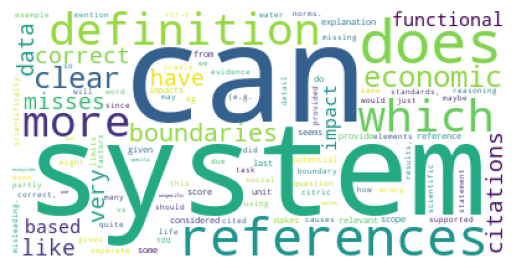

In [41]:
# Join all answers to get a single piece of text
all_answers_text=' '.join(combined_final.T7.drop_duplicates().to_list())
all_answers_text.replace('\n',' ')

# Custom frequencies calculation
all_answers_frequencies = get_frequency_dict_for_text(all_answers_text)

# Create wordcloud
wordcloud_obj = WordCloud(background_color="white")
wordcloud_obj.generate_from_frequencies(all_answers_frequencies)

plt.grid(visible=False,which='both',axis='both')
plt.axis("off")
plt.imshow(wordcloud_obj)
plt.show()

In [43]:
# Get sentiment
q2_extra_comments = combined_final.loc[:, 'T7'].drop_duplicates()
q2_extra_comments = pd.DataFrame({'response_id':q2_extra_comments.index, 'comment':q2_extra_comments.values})


In [44]:
# Sentiment using FLAIR https://github.com/flairNLP/flair
# Flair gives better quality sentiment analyses on this type of dataset than VADER, as it is trained on longer-form movie reviews whereas NLTK's VADER is trained on short-form informal social media posts
from flair.data import Sentence
from flair.nn import Classifier

# load the NER tagger
tagger = Classifier.load('sentiment')

def get_sentiment_flair(x, tagger):
    sentence = Sentence(x)
    tagger.predict(sentence)
    return pd.Series([sentence.get_label().value, sentence.get_label().score])


In [45]:
q2_extra_comments[['sentiment_flair_label', 'sentiment_flair_confidence']] = q2_extra_comments.comment.dropna().apply(get_sentiment_flair, tagger=tagger)

2025-06-18 11:47:35,036 Warning: An empty Sentence was created! Are there empty strings in your dataset?


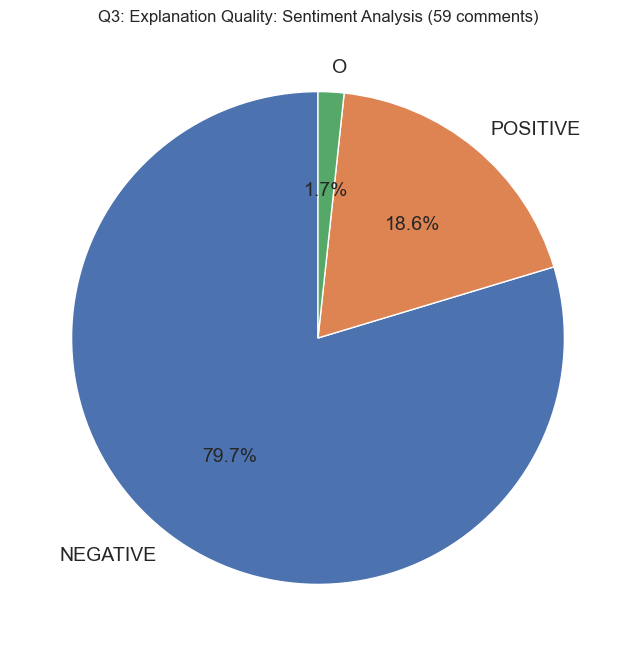

In [47]:
plt.figure(figsize=(8, 8))
sentiment_pivot = q2_extra_comments.sentiment_flair_label.value_counts()
plt.pie(sentiment_pivot, labels=sentiment_pivot.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 14})
plt.title(f'Q2: Scientific Accuracy: Sentiment Analysis ({q2_extra_comments.shape[0]} comments)')
plt.show()